# Анализ пассажиропотока: кластеризация + прогноз (1ч и 24ч)
Данные: метро/НГПТ/МЦД, часовая агрегация. Логика праздников заложена, но на этой неделе их нет.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import os, gc, warnings, zipfile, re
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from datetime import timedelta

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (16, 5), 'font.size': 11})

## Загрузка архива

In [2]:
import gdown
file_id = '1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'data.zip', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM
From (redirected): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM&confirm=t&uuid=0d640169-da83-43a1-a8d8-69db2583db8d
To: /kaggle/working/data.zip
100%|██████████| 2.51G/2.51G [00:22<00:00, 111MB/s] 


'data.zip'

In [3]:
DATA_DIR = './data/'
with zipfile.ZipFile('/kaggle/working/data.zip', 'r') as z:
    z.extractall(DATA_DIR)
with zipfile.ZipFile('/kaggle/working/data/Метро НБС/pass_10-160324.zip', 'r') as z:
    z.extractall(DATA_DIR)

## 1. Справочники

In [4]:
ref_places = pd.read_csv(f'{DATA_DIR}REF_PSG_PLACES_202503251822.csv', sep=';')
ref_transport = pd.read_csv(f'{DATA_DIR}REF_TRANSPORT_TYPE_202503251727.csv', sep=';')
ref_routes = pd.read_csv(f'{DATA_DIR}REF_TRANSPORT_WAY_202503251803.csv', sep=';')
gds_goods = pd.read_csv(f'{DATA_DIR}GDS_GOODS_202503251844.csv', sep=';')
gds_app = pd.read_csv(f'{DATA_DIR}GDS_APPLICATION_202503251731.csv', sep=';')
gds_transfer = pd.read_csv(f'{DATA_DIR}GDS_TRANSFER_202503251738.csv', sep=';')

rows = []
with open(f'{DATA_DIR}V_PCR_CONTRACTOR_202503251702.csv', 'r', encoding='utf-8') as f:
    for line in f:
        for m in re.findall(r'(\d+);;([^0-9]+?)(?=\d+;;|$)', line):
            rows.append({'ID': int(m[0]), 'PARENT_ID': None, 'NAME_SHORT': m[1].strip()})
pcr_contr = pd.DataFrame(rows)

print(f"ref_places: {len(ref_places)}, ref_transport: {len(ref_transport)}, "
      f"ref_routes: {len(ref_routes)}, gds_goods: {len(gds_goods)}, pcr_contr: {len(pcr_contr)}")

ref_places: 3141, ref_transport: 10, ref_routes: 2490, gds_goods: 432, pcr_contr: 2121


## 2. Чанковая загрузка -> часовая агрегация

In [5]:
USE_COLS = ['TRAN_DATE','PLACE_ID','TRANSPORT_TYPE_ID','BUS_RT_NO',
            'AGENT_ID','GD_ID','TRANSFER_TYPE_ID','VALIDATION_MODE',
            'CPPC_VALIDATION_TYPE','IS_FAIL','CRD_NO']
GROUP_KEYS = ['date_hour','PLACE_ID','TRANSPORT_TYPE_ID','BUS_RT_NO',
              'AGENT_ID','GD_ID','TRANSFER_TYPE_ID','VALIDATION_MODE',
              'CPPC_VALIDATION_TYPE']

CHUNK = 3_000_000
agg_parts, n_total = [], 0

reader = pd.read_csv(f'{DATA_DIR}PASS_ALL_202503242210.csv', sep=';',
                     usecols=USE_COLS, parse_dates=['TRAN_DATE'],
                     chunksize=CHUNK, low_memory=False)

for i, ch in enumerate(reader):
    n_total += len(ch)
    ch = ch[ch['IS_FAIL'] != 1].copy()
    ch['date_hour'] = ch['TRAN_DATE'].dt.floor('h')
    agg = ch.groupby(GROUP_KEYS, dropna=False).agg(
        pax=('TRAN_DATE', 'size'), unique_cards=('CRD_NO', 'nunique')
    ).reset_index()
    agg_parts.append(agg)
    del ch, agg; gc.collect()
    if (i+1) % 10 == 0:
        mem = sum(x.memory_usage(deep=True).sum() for x in agg_parts) / 1e9
        print(f"  chunk {i+1}: {n_total:,} строк, ~{mem:.2f} ГБ в RAM")

print(f"Итого: {n_total:,}")
hourly = pd.concat(agg_parts, ignore_index=True)
del agg_parts; gc.collect()
hourly = hourly.groupby(GROUP_KEYS, dropna=False).agg(
    pax=('pax','sum'), unique_cards=('unique_cards','sum')
).reset_index()
print(f"hourly: {len(hourly):,} строк, {hourly.memory_usage(deep=True).sum()/1e6:.0f} МБ")

  chunk 10: 30,000,000 строк, ~0.15 ГБ в RAM
  chunk 20: 60,000,000 строк, ~0.31 ГБ в RAM
  chunk 30: 89,150,313 строк, ~0.49 ГБ в RAM
Итого: 89,150,313
hourly: 4,982,384 строк, 438 МБ


## 3. Обогащение + праздники

In [6]:
hourly = hourly.merge(
    ref_places[['PLACE_ID','TYPE_ID','ST_CODE','ST_NAME','LN_CODE','LN_NAME','IS_TEST']],
    on='PLACE_ID', how='left')
hourly = hourly[hourly['IS_TEST'] != 1].drop(columns='IS_TEST')

hourly = hourly.merge(
    ref_transport.rename(columns={'TRANSPORT_ID':'TRANSPORT_TYPE_ID','NAME':'TRANSPORT_NAME'}),
    on='TRANSPORT_TYPE_ID', how='left')
hourly = hourly.merge(
    ref_routes[['WAY_ID','NAME']].rename(columns={'WAY_ID':'BUS_RT_NO','NAME':'ROUTE_NAME'}),
    on='BUS_RT_NO', how='left')
hourly = hourly.merge(
    pcr_contr[['ID','NAME_SHORT']].rename(columns={'ID':'AGENT_ID','NAME_SHORT':'AGENT_NAME'}),
    on='AGENT_ID', how='left')
hourly = hourly.merge(
    gds_goods[['GD_ID','NAME_SHORT','ARCHITECT_ID']].rename(columns={'NAME_SHORT':'TICKET_NAME'}),
    on='GD_ID', how='left')

def transport_cat(row):
    if pd.notna(row['BUS_RT_NO']): return 'НГПТ'
    if row['TYPE_ID'] == 1: return 'Метро'
    if row['TYPE_ID'] == 15: return 'МЦД'
    return 'Другое'

hourly['tcat'] = hourly.apply(transport_cat, axis=1)
hourly['hour'] = hourly['date_hour'].dt.hour
hourly['date'] = hourly['date_hour'].dt.normalize()
hourly['dow'] = hourly['date_hour'].dt.dayofweek
hourly['month'] = hourly['date_hour'].dt.month
hourly['is_wknd'] = (hourly['dow'] >= 5).astype(int)

# праздники РФ (на текущей неделе 10-16 марта их нет, но фича заложена для масштабирования)
hol_md = [(1,1),(1,2),(1,3),(1,4),(1,5),(1,6),(1,7),(1,8),
          (2,23),(3,8),(5,1),(5,9),(6,12),(11,4)]
hourly['md'] = list(zip(hourly['date_hour'].dt.month, hourly['date_hour'].dt.day))
hourly['is_hol'] = hourly['md'].isin(hol_md).astype(int)
hourly.drop('md', axis=1, inplace=True)

print(hourly.groupby('tcat')['pax'].sum().sort_values(ascending=False))

tcat
Метро    49532102
НГПТ     30591283
МЦД       9021493
Name: pax, dtype: int64


## 4. Профили для кластеризации

In [7]:
def build_profiles(subset, id_col, name_col):
    subset = subset.copy()
    subset['is_wknd'] = (subset['dow'] >= 5).astype(int)
    rows = []
    for oid in subset[id_col].dropna().unique():
        d = subset[subset[id_col] == oid]
        name = d[name_col].iloc[0] if name_col in d.columns else '?'
        wd = d[d['is_wknd']==0]
        nd_wd = wd['date'].nunique()
        if nd_wd == 0: continue
        wd_h = wd.groupby('hour')['pax'].sum() / nd_wd
        wd_tot = wd_h.sum()
        if wd_tot == 0: continue

        we = d[d['is_wknd']==1]
        nd_we = we['date'].nunique()
        we_h = we.groupby('hour')['pax'].sum() / nd_we if nd_we > 0 else pd.Series(dtype=float)
        we_tot = we_h.sum() if nd_we > 0 else 0

        r = {'object_id': oid, 'object_name': name, 'daily_volume': wd_tot}
        for h in range(24):
            r[f'wd_h{h}'] = wd_h.get(h,0) / wd_tot
            r[f'we_h{h}'] = (we_h.get(h,0) / we_tot) if we_tot > 0 else 0

        morn = sum(wd_h.get(h,0) for h in [7,8,9])
        eve  = sum(wd_h.get(h,0) for h in [17,18,19])
        r['morn_eve_ratio'] = morn/eve if eve > 0 else 1.0
        r['we_wd_ratio'] = we_tot/wd_tot if wd_tot > 0 else 0
        r['peakiness'] = wd_h.max() / (wd_tot/24)
        r['night_share'] = sum(wd_h.get(h,0) for h in [23,0,1,2,3,4,5]) / wd_tot
        r['midday_share'] = sum(wd_h.get(h,0) for h in [11,12,13,14]) / wd_tot
        rows.append(r)
    return pd.DataFrame(rows)

metro = hourly[hourly['tcat']=='Метро']
metro_f = build_profiles(metro, 'ST_CODE', 'ST_NAME')
metro_f['transport'] = 'Метро'
st_map = metro.drop_duplicates('ST_CODE').set_index('ST_CODE')
metro_f['LN_CODE'] = metro_f['object_id'].map(st_map['LN_CODE'])
metro_f['LN_NAME'] = metro_f['object_id'].map(st_map['LN_NAME'])

ngpt = hourly[hourly['tcat']=='НГПТ']
ngpt_f = build_profiles(ngpt, 'BUS_RT_NO', 'ROUTE_NAME')
ngpt_f['transport'] = 'НГПТ'
ngpt_f['LN_CODE'] = ngpt_f['LN_NAME'] = None

parts = [metro_f, ngpt_f]
mcd = hourly[hourly['tcat']=='МЦД']
if mcd['ST_CODE'].nunique() > 2:
    mcd_f = build_profiles(mcd, 'ST_CODE', 'ST_NAME')
    mcd_f['transport'] = 'МЦД'
    sm = mcd.drop_duplicates('ST_CODE').set_index('ST_CODE')
    mcd_f['LN_CODE'] = mcd_f['object_id'].map(sm['LN_CODE'])
    mcd_f['LN_NAME'] = mcd_f['object_id'].map(sm['LN_NAME'])
    parts.append(mcd_f)

all_feat = pd.concat(parts, ignore_index=True)
print(f"Всего: {len(all_feat)} (Метро: {(all_feat.transport=='Метро').sum()}, "
      f"НГПТ: {(all_feat.transport=='НГПТ').sum()}, МЦД: {(all_feat.transport=='МЦД').sum()})")

Всего: 1646 (Метро: 314, НГПТ: 1035, МЦД: 297)


## 5. Кластеризация

In [8]:
af = all_feat[(all_feat['daily_volume'] >= 50) & (all_feat['peakiness'] < 15) & (all_feat['we_wd_ratio'] > 0)].copy()
af['object_name'] = af['object_name'].fillna(af['transport']+'_'+af['object_id'].astype(str))
af['log_volume'] = np.log1p(af['daily_volume'])

profile_cols = [f'wd_h{h}' for h in range(24)]
feat_cols = profile_cols + ['morn_eve_ratio','we_wd_ratio','peakiness','night_share','midday_share','log_volume']
X = StandardScaler().fit_transform(af[feat_cols].values)

res = []
for k in range(4, 15):
    lab = KMeans(k, n_init=30, random_state=42).fit_predict(X)
    sizes = pd.Series(lab).value_counts()
    res.append({'k': k, 'sil': silhouette_score(X, lab), 'min_cl': sizes.min(), 'max_share': sizes.max()/len(lab)})
rdf = pd.DataFrame(res)

good = rdf[(rdf.max_share < 0.40) & (rdf.min_cl >= 10)]
if len(good) == 0: good = rdf[rdf.max_share < 0.50]
best_k = int(good.loc[good.sil.idxmax(), 'k'])
print(f"k={best_k}")

km = KMeans(best_k, n_init=50, random_state=42)
af['cluster'] = km.fit_predict(X)

sizes = af['cluster'].value_counts()
small = sizes[sizes < 10].index.tolist()
if small:
    centers = km.cluster_centers_
    for sc in small:
        dists = np.linalg.norm(centers - centers[sc], axis=1)
        dists[sc] = np.inf
        for s2 in small:
            if s2 != sc: dists[s2] = np.inf
        af.loc[af.cluster == sc, 'cluster'] = np.argmin(dists)
    mapping = {old: new for new, old in enumerate(sorted(af.cluster.unique()))}
    af['cluster'] = af.cluster.map(mapping)

final_k = af.cluster.nunique()
print(f"Кластеров: {final_k}")

k=11
Кластеров: 8


In [9]:
os.makedirs('./eda_output', exist_ok=True)
hourly.to_parquet('./eda_output/hourly.parquet', index=False)

cluster_names = {}
for c in sorted(af.cluster.unique()):
    s = af[af.cluster==c]
    me, vol = s.morn_eve_ratio.mean(), s.daily_volume.mean()
    nm = "Жилой" if me>1.3 else ("Деловой" if me<0.75 else "Смешанный")
    nm += " крупный" if vol>20000 else (" средний" if vol>5000 else (" малый" if vol>1000 else " мелкий"))
    dom = s.transport.value_counts()
    if dom.iloc[0]/len(s) > 0.7: nm += f" ({dom.index[0]})"
    cluster_names[c] = nm

af['cluster_name'] = af.cluster.map(cluster_names)
save_cols = ['object_id','object_name','transport','cluster','cluster_name',
             'LN_CODE','LN_NAME','daily_volume','log_volume',
             'morn_eve_ratio','we_wd_ratio','peakiness','night_share','midday_share']
af[save_cols].to_csv('./eda_output/final_clusters.csv', index=False)

---
# Прогнозирование: 24ч и 1ч

In [10]:
OUTPUT_DIR = './eda_output/'
hourly = pd.read_parquet(f'{OUTPUT_DIR}hourly.parquet')
clusters = pd.read_csv(f'{OUTPUT_DIR}final_clusters.csv')

def clean_id(v):
    s = str(v)
    return s[:-2] if s.endswith('.0') else s

def get_obj_id(row):
    if pd.notna(row.get('BUS_RT_NO')): return f"RT_{clean_id(row['BUS_RT_NO'])}"
    if pd.notna(row.get('ST_CODE')): return f"ST_{clean_id(row['ST_CODE'])}"
    if pd.notna(row.get('PLACE_ID')): return f"PL_{clean_id(row['PLACE_ID'])}"
    return None

hourly['object_id'] = hourly.apply(get_obj_id, axis=1)
hourly = hourly[hourly.object_id.notna()]
ts_data = hourly.groupby(['date_hour','object_id'])['pax'].sum().reset_index()

clusters['object_id_str'] = clusters.transport.map(
    {'Метро':'ST_','МЦД':'ST_','НГПТ':'RT_'}) + clusters.object_id.apply(clean_id)

ts_data = ts_data.merge(
    clusters[['object_id_str','cluster','cluster_name','transport','daily_volume']]
    .rename(columns={'object_id_str':'object_id'}),
    on='object_id', how='left')

ts_data['hour'] = ts_data.date_hour.dt.hour
ts_data['dow'] = ts_data.date_hour.dt.dayofweek
ts_data['date'] = ts_data.date_hour.dt.date

ts_ids = set(ts_data.object_id.unique())
matched = ts_ids & set(clusters.object_id_str.unique())
print(f"Совпало: {len(matched)} из {len(ts_ids)}")

Совпало: 1542 из 1659


## Модели и утилиты

In [11]:
HORIZON_24 = 24
HORIZON_1 = 1
N_HOURS = 168
dow_names = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

def prepare_ts(object_id, data=ts_data):
    d = data[data.object_id == object_id].copy()
    if len(d) == 0: return None
    full = pd.date_range(data.date_hour.min(), data.date_hour.max(), freq='h')
    return d.set_index('date_hour')['pax'].reindex(full, fill_value=0).rename_axis('datetime')

def metrics(yt, yp, name=""):
    yt, yp = np.array(yt, float), np.array(yp, float)
    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    smape = np.mean(2*np.abs(yt-yp) / (np.abs(yt)+np.abs(yp)+1e-8)) * 100
    # исправлено: защита от деления на 0 ночью
    mape = np.mean(np.abs(yt-yp) / np.maximum(np.abs(yt), 1)) * 100
    return {'model':name, 'MAE':round(mae,2), 'RMSE':round(rmse,2),
            'SMAPE':round(smape,2), 'MAPE':round(mape,2)}

def seasonal_naive(y, h, s=24):
    return np.array([y[-(s) + i%s] for i in range(h)])

def mean_profile(y, h, s=24):
    days = len(y)//s
    return np.tile(y[:days*s].reshape(days,s).mean(0), h//s+1)[:h]

def weighted_profile(y, h, s=24):
    days = len(y)//s
    d = y[:days*s].reshape(days,s)
    w = np.exp(np.linspace(-1,0,days)); w /= w.sum()
    return np.tile(np.average(d, axis=0, weights=w), h//s+1)[:h]

def same_type_day(y, h, test_dow, s=24):
    days = len(y)//s
    d = y[:days*s].reshape(days,s)
    is_we = test_dow >= 5
    idx = [i for i in range(days) if (i%7 >= 5) == is_we]
    prof = d[idx].mean(0) if idx else d.mean(0)
    return np.tile(prof, h//s+1)[:h]

def holiday_aware_naive(y, h, test_dow, is_hol, s=24):
    eff_dow = 6 if is_hol else test_dow
    pred = same_type_day(y, h, eff_dow, s)
    return np.maximum(pred, 0)

class ImprovedETS:
    def __init__(self, sp=24):
        self.sp = sp

    def fit_predict(self, y_train, steps, test_dow=None, is_hol=0):
        y = np.array(y_train, float)
        sp = self.sp
        if len(y) < 2*sp:
            return mean_profile(y, steps, sp)

        cands = {
            'mean': mean_profile(y, steps, sp),
            'weighted': weighted_profile(y, steps, sp),
            'seasonal': seasonal_naive(y, steps, sp),
        }
        if test_dow is not None:
            cands['same_type'] = same_type_day(y, steps, test_dow, sp)
            cands['hol_aware'] = holiday_aware_naive(y, steps, test_dow, is_hol, sp)

        for stype in ['add', 'mul']:
            try:
                yf = np.maximum(y, 1) if stype=='mul' else y
                m = ExponentialSmoothing(yf, trend=None, seasonal=stype,
                    seasonal_periods=sp, initialization_method='estimated').fit(optimized=True)
                cands[f'ets_{stype}'] = m.forecast(steps)
            except: pass

        y_val, y_sub = y[-sp:], y[:-sp]
        val_dow = (len(y_sub)//sp) % 7
        best_name, best_mae = 'mean', np.inf

        for nm in cands:
            try:
                if nm == 'seasonal': vp = seasonal_naive(y_sub, sp, sp)
                elif nm == 'mean': vp = mean_profile(y_sub, sp, sp)
                elif nm == 'weighted': vp = weighted_profile(y_sub, sp, sp)
                elif nm == 'same_type': vp = same_type_day(y_sub, sp, val_dow, sp)
                elif nm == 'hol_aware': vp = holiday_aware_naive(y_sub, sp, val_dow, is_hol, sp)
                elif 'ets' in nm:
                    st = 'mul' if 'mul' in nm else 'add'
                    yf = np.maximum(y_sub, 1) if st=='mul' else y_sub
                    vp = ExponentialSmoothing(yf, trend=None, seasonal=st,
                        seasonal_periods=sp, initialization_method='estimated').fit(optimized=True).forecast(sp)
                else: continue
                mae = np.mean(np.abs(y_val - vp[:len(y_val)]))
                if mae < best_mae: best_mae, best_name = mae, nm
            except: continue

        return np.maximum(cands.get(best_name, cands['mean']), 0)

class CleanEnsemble:
    def fit_predict(self, y_train, steps, test_dow, is_hol=0):
        sp = 24
        if len(y_train) < 2*sp:
            return mean_profile(y_train, steps, sp)

        y_sub, y_val = y_train[:-sp], y_train[-sp:]
        vd = (len(y_sub)//sp) % 7

        models_val = {
            'seasonal': seasonal_naive(y_sub, sp, sp),
            'same_type': same_type_day(y_sub, sp, vd, sp),
            'hol_aware': holiday_aware_naive(y_sub, sp, vd, is_hol, sp),
            'weighted': weighted_profile(y_sub, sp, sp),
        }
        scores = {n: mean_absolute_error(y_val, p[:len(y_val)])+1e-8 for n, p in models_val.items()}
        tot = sum(1/s for s in scores.values())
        w = {n: (1/s)/tot for n, s in scores.items()}

        models_test = {
            'seasonal': seasonal_naive(y_train, steps, sp),
            'same_type': same_type_day(y_train, steps, test_dow, sp),
            'hol_aware': holiday_aware_naive(y_train, steps, test_dow, is_hol, sp),
            'weighted': weighted_profile(y_train, steps, sp),
        }
        return np.maximum(sum(w[n]*models_test[n] for n in w), 0)

class MinimalKNN:
    def __init__(self, k=3):
        self.k = k; self.scaler = StandardScaler()

    def fit(self, ts):
        v = ts.values
        self.mu = np.mean(v[v>0]) if (v>0).any() else 1
        X, y = [], []
        for i in range(24, len(v)):
            h = ts.index[i].hour
            X.append([np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24), v[i-24]/self.mu])
            y.append(v[i]/self.mu)
        X, y = np.array(X), np.array(y)
        self.scaler.fit(X)
        k = min(self.k, len(X)-1, 3)
        self.model = KNeighborsRegressor(max(k,1), weights='distance')
        self.model.fit(self.scaler.transform(X), y)
        self.vals, self.idx = v, ts.index
        return self

    def predict(self, steps):
        preds = []
        for i in range(steps):
            h = (self.idx[-1] + timedelta(hours=i+1)).hour
            li = len(self.vals)-24+i
            lag = self.vals[li]/self.mu if 0<=li<len(self.vals) else 1
            x = np.array([[np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24), lag]])
            preds.append(max(0, self.model.predict(self.scaler.transform(x))[0]*self.mu))
        return np.array(preds)

## Подготовка объектов

In [12]:
cluster_series = {}
found = not_found = 0

for cid in clusters.cluster.unique():
    objs = clusters[clusters.cluster == cid]
    sd = {}
    for _, r in objs.iterrows():
        ts = prepare_ts(r.object_id_str)
        if ts is not None and ts.sum() > 0:
            sd[r.object_id_str] = ts; found += 1
        else: not_found += 1
    cluster_series[cid] = sd

print(f"Найдено: {found}, нет: {not_found}")

all_obj = clusters[['object_id_str','object_name','cluster','transport','daily_volume']].rename(
    columns={'object_id_str':'object_id','object_name':'name'}).drop_duplicates('object_id')
all_obj = all_obj[all_obj.object_id.isin(ts_ids)].copy()
print(f"Для оценки: {len(all_obj)} объектов")

Найдено: 1542, нет: 0
Для оценки: 1542 объектов


## CV: 24ч вперёд

In [13]:
def get_folds(n=N_HOURS, h=HORIZON_24, min_days=2):
    return [{'te': t, 'ts': t, 'tf': t+h, 'td': t//24}
            for t in range(min_days*24, n-h+1, 24)]

folds_24 = get_folds()
all_results_24 = []
processed = 0

def check_holiday(ts_obj, fold_start):
    dt = ts_obj.index[fold_start]
    return int((dt.month, dt.day) in hol_md)

print(f"CV 24ч: {len(all_obj)} объектов × {len(folds_24)} фолдов")

for oi, (_, obj) in enumerate(all_obj.iterrows()):
    oid, cid = obj.object_id, obj.cluster
    ts = prepare_ts(oid)
    if ts is None or ts.sum() == 0: continue

    for fi, fold in enumerate(folds_24):
        y_tr = ts.iloc[:fold['te']].values
        y_te = ts.iloc[fold['ts']:fold['tf']].values
        ts_tr = ts.iloc[:fold['te']]
        if len(y_te)==0 or y_te.sum()==0: continue
        td = ts.index[fold['ts']].dayofweek
        is_hol = check_holiday(ts, fold['ts'])

        preds = {
            'Seasonal Naive': seasonal_naive(y_tr, HORIZON_24),
            'Mean Profile': mean_profile(y_tr, HORIZON_24),
            'Weighted Profile': weighted_profile(y_tr, HORIZON_24),
            'Same-Type Day': same_type_day(y_tr, HORIZON_24, td),
            'Holiday-Aware': holiday_aware_naive(y_tr, HORIZON_24, td, is_hol),
            'ETS': ImprovedETS().fit_predict(y_tr, HORIZON_24, td, is_hol),
            'Clean Ensemble': CleanEnsemble().fit_predict(y_tr, HORIZON_24, td, is_hol),
        }

        if len(y_tr) >= 48:
            try:
                knn = MinimalKNN(3).fit(ts_tr)
                preds['k-NN minimal'] = knn.predict(HORIZON_24)
            except: pass

        for mn, pred in preds.items():
            m = metrics(y_te, pred, mn)
            m.update({'object_id':oid, 'cluster':cid, 'transport':obj.transport,
                      'volume':obj.daily_volume, 'fold':fi, 'horizon':24,
                      'test_day':dow_names[td], 'is_hol':is_hol})
            all_results_24.append(m)

    processed += 1
    if (oi+1) % 200 == 0:
        print(f"  {oi+1}/{len(all_obj)} | done={processed}")

res_24 = pd.DataFrame(all_results_24)
print(f"24ч готово: {processed} объектов, {len(res_24):,} записей")

CV 24ч: 1542 объектов × 5 фолдов
  200/1542 | done=200
  400/1542 | done=400
  600/1542 | done=600
  800/1542 | done=800
  1000/1542 | done=1000
  1200/1542 | done=1200
  1400/1542 | done=1400
24ч готово: 1542 объектов, 61,464 записей


## CV: 1ч вперёд
ETS убран намеренно: на 1 неделе данных он слишком медленный для 180к итераций, а простые лаги работают лучше.

In [14]:
folds_1 = list(range(48, N_HOURS))
all_results_1 = []
processed = 0

print(f"CV 1ч: {len(all_obj)} объектов × {len(folds_1)} фолдов")

for oi, (_, obj) in enumerate(all_obj.iterrows()):
    oid, cid = obj.object_id, obj.cluster
    ts = prepare_ts(oid)
    if ts is None or ts.sum() == 0: continue

    for fi, t in enumerate(folds_1):
        y_tr = ts.iloc[:t].values
        y_te = [ts.iloc[t]]
        td = ts.index[t].dayofweek
        is_hol = check_holiday(ts, t)

        preds = {
            'Naive-1': np.array([y_tr[-1]]),
            'Seasonal-24': np.array([y_tr[-24]]),
            'Mean-3': np.array([np.mean(y_tr[-3:])]),
            'Holiday-Aware': holiday_aware_naive(y_tr, 1, td, is_hol),
            'Clean Ensemble': CleanEnsemble().fit_predict(y_tr, 1, td, is_hol),
        }

        for mn, pred in preds.items():
            m = metrics(y_te, pred, mn)
            m.update({'object_id':oid, 'cluster':cid, 'transport':obj.transport,
                      'volume':obj.daily_volume, 'fold':fi, 'horizon':1,
                      'test_day':dow_names[td], 'is_hol':is_hol})
            all_results_1.append(m)

    processed += 1
    if (oi+1) % 200 == 0:
        print(f"  {oi+1}/{len(all_obj)} | done={processed}")

res_1 = pd.DataFrame(all_results_1)
print(f"1ч готово: {processed} объектов, {len(res_1):,} записей")

CV 1ч: 1542 объектов × 120 фолдов
  200/1542 | done=200
  400/1542 | done=400
  600/1542 | done=600
  800/1542 | done=800
  1000/1542 | done=1000
  1200/1542 | done=1200
  1400/1542 | done=1400
1ч готово: 1542 объектов, 925,200 записей


## Результаты

In [21]:
def print_results(df, horizon_name):
    final = df.groupby('model').agg(
        MAE=('MAE','mean'), MAE_med=('MAE','median'), SMAPE=('SMAPE','mean'),
        MAPE=('MAPE','mean'), n=('MAE','count')
    ).round(2).sort_values('MAE')

    print(f"\n{'_'*70}")
    print(f"РЕЙТИНГ {horizon_name} ({df.object_id.nunique()} объектов × {df.fold.nunique()} фолдов)")
    print(f"{'_'*70}")
    for i, (m, r) in enumerate(final.iterrows()):
        medal = ['1','2','3'][i] if i<3 else '  '
        print(f"  {medal} {m:<20} MAE={r.MAE:>7.2f} (med={r.MAE_med:>6.2f})  SMAPE={r.SMAPE:>5.2f}%  MAPE={r.MAPE:>5.2f}%")
    return final

fin_24 = print_results(res_24, "24ч")
fin_1 = print_results(res_1, "1ч")


______________________________________________________________________
РЕЙТИНГ 24ч (1542 объектов × 5 фолдов)
______________________________________________________________________
  1 Holiday-Aware        MAE=  62.16 (med= 25.71)  SMAPE=31.74%  MAPE=88.36%
  2 Same-Type Day        MAE=  62.16 (med= 25.71)  SMAPE=31.74%  MAPE=88.36%
  3 Seasonal Naive       MAE=  62.33 (med= 28.38)  SMAPE=32.04%  MAPE=88.93%
     Clean Ensemble       MAE=  66.21 (med= 27.39)  SMAPE=33.61%  MAPE=90.96%
     ETS                  MAE=  68.49 (med= 28.00)  SMAPE=36.60%  MAPE=108.40%
     k-NN minimal         MAE=  70.36 (med= 30.75)  SMAPE=35.10%  MAPE=99.02%
     Weighted Profile     MAE=  82.65 (med= 29.81)  SMAPE=36.25%  MAPE=102.25%
     Mean Profile         MAE=  85.77 (med= 29.87)  SMAPE=36.53%  MAPE=103.96%

______________________________________________________________________
РЕЙТИНГ 1ч (1542 объектов × 120 фолдов)
______________________________________________________________________
  1 Seasona

In [20]:
print("\n--- Влияние праздников (24ч) ---")
for lbl, mask in [('Обычный день', res_24.is_hol==0), ('Праздник', res_24.is_hol==1)]:
    sub = res_24[mask]
    if len(sub) == 0: 
        print(f"\n{lbl}: нет данных (на этой неделе праздников не выпало)")
        continue
    s = sub.groupby('model')['MAE'].mean().sort_values()
    print(f"\n{lbl} ({len(sub)} записей):")
    for j, (m, v) in enumerate(s.head(3).items()):
        print(f"  {'123'[j] if j<3 else ' '} {m:<20} {v:.2f}")


--- Влияние праздников (24ч) ---

Обычный день (61464 записей):
  1 Holiday-Aware        62.16
  2 Same-Type Day        62.16
  3 Seasonal Naive       62.33

Праздник: нет данных (на этой неделе праздников не выпало)


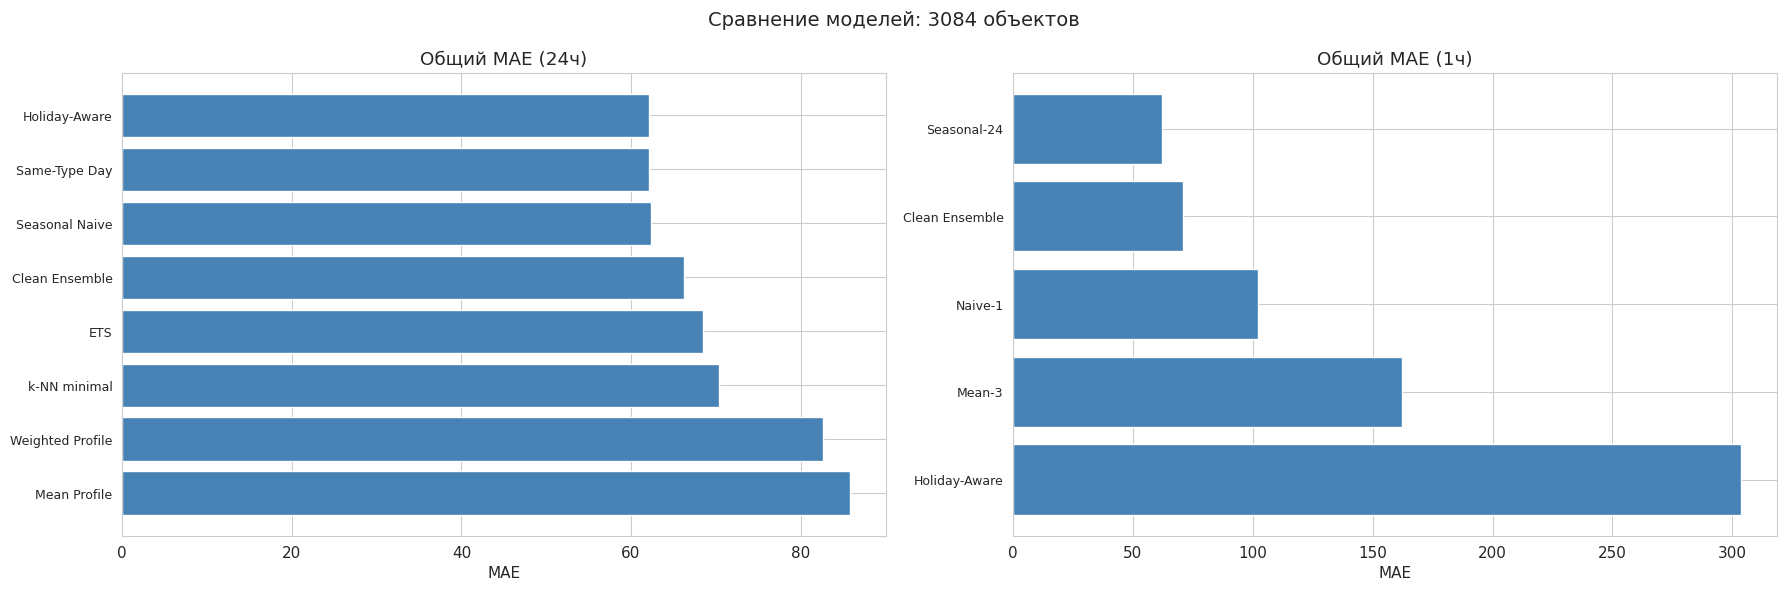

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df, fin, title in zip(axes, [res_24, res_1], [fin_24, fin_1], ["24ч", "1ч"]):
    models_order = fin.index.tolist()
    ax.barh(range(len(fin)), fin.MAE.values, color='steelblue')
    ax.set_yticks(range(len(fin))); ax.set_yticklabels(models_order, fontsize=9)
    ax.set_xlabel('MAE'); ax.set_title(f'Общий MAE ({title})'); ax.invert_yaxis()

plt.suptitle(f'Сравнение моделей: {res_24.object_id.nunique()+res_1.object_id.nunique()} объектов', fontsize=14)
plt.tight_layout(); plt.savefig('./eda_output/baseline_24_1h.png', dpi=150); plt.show()

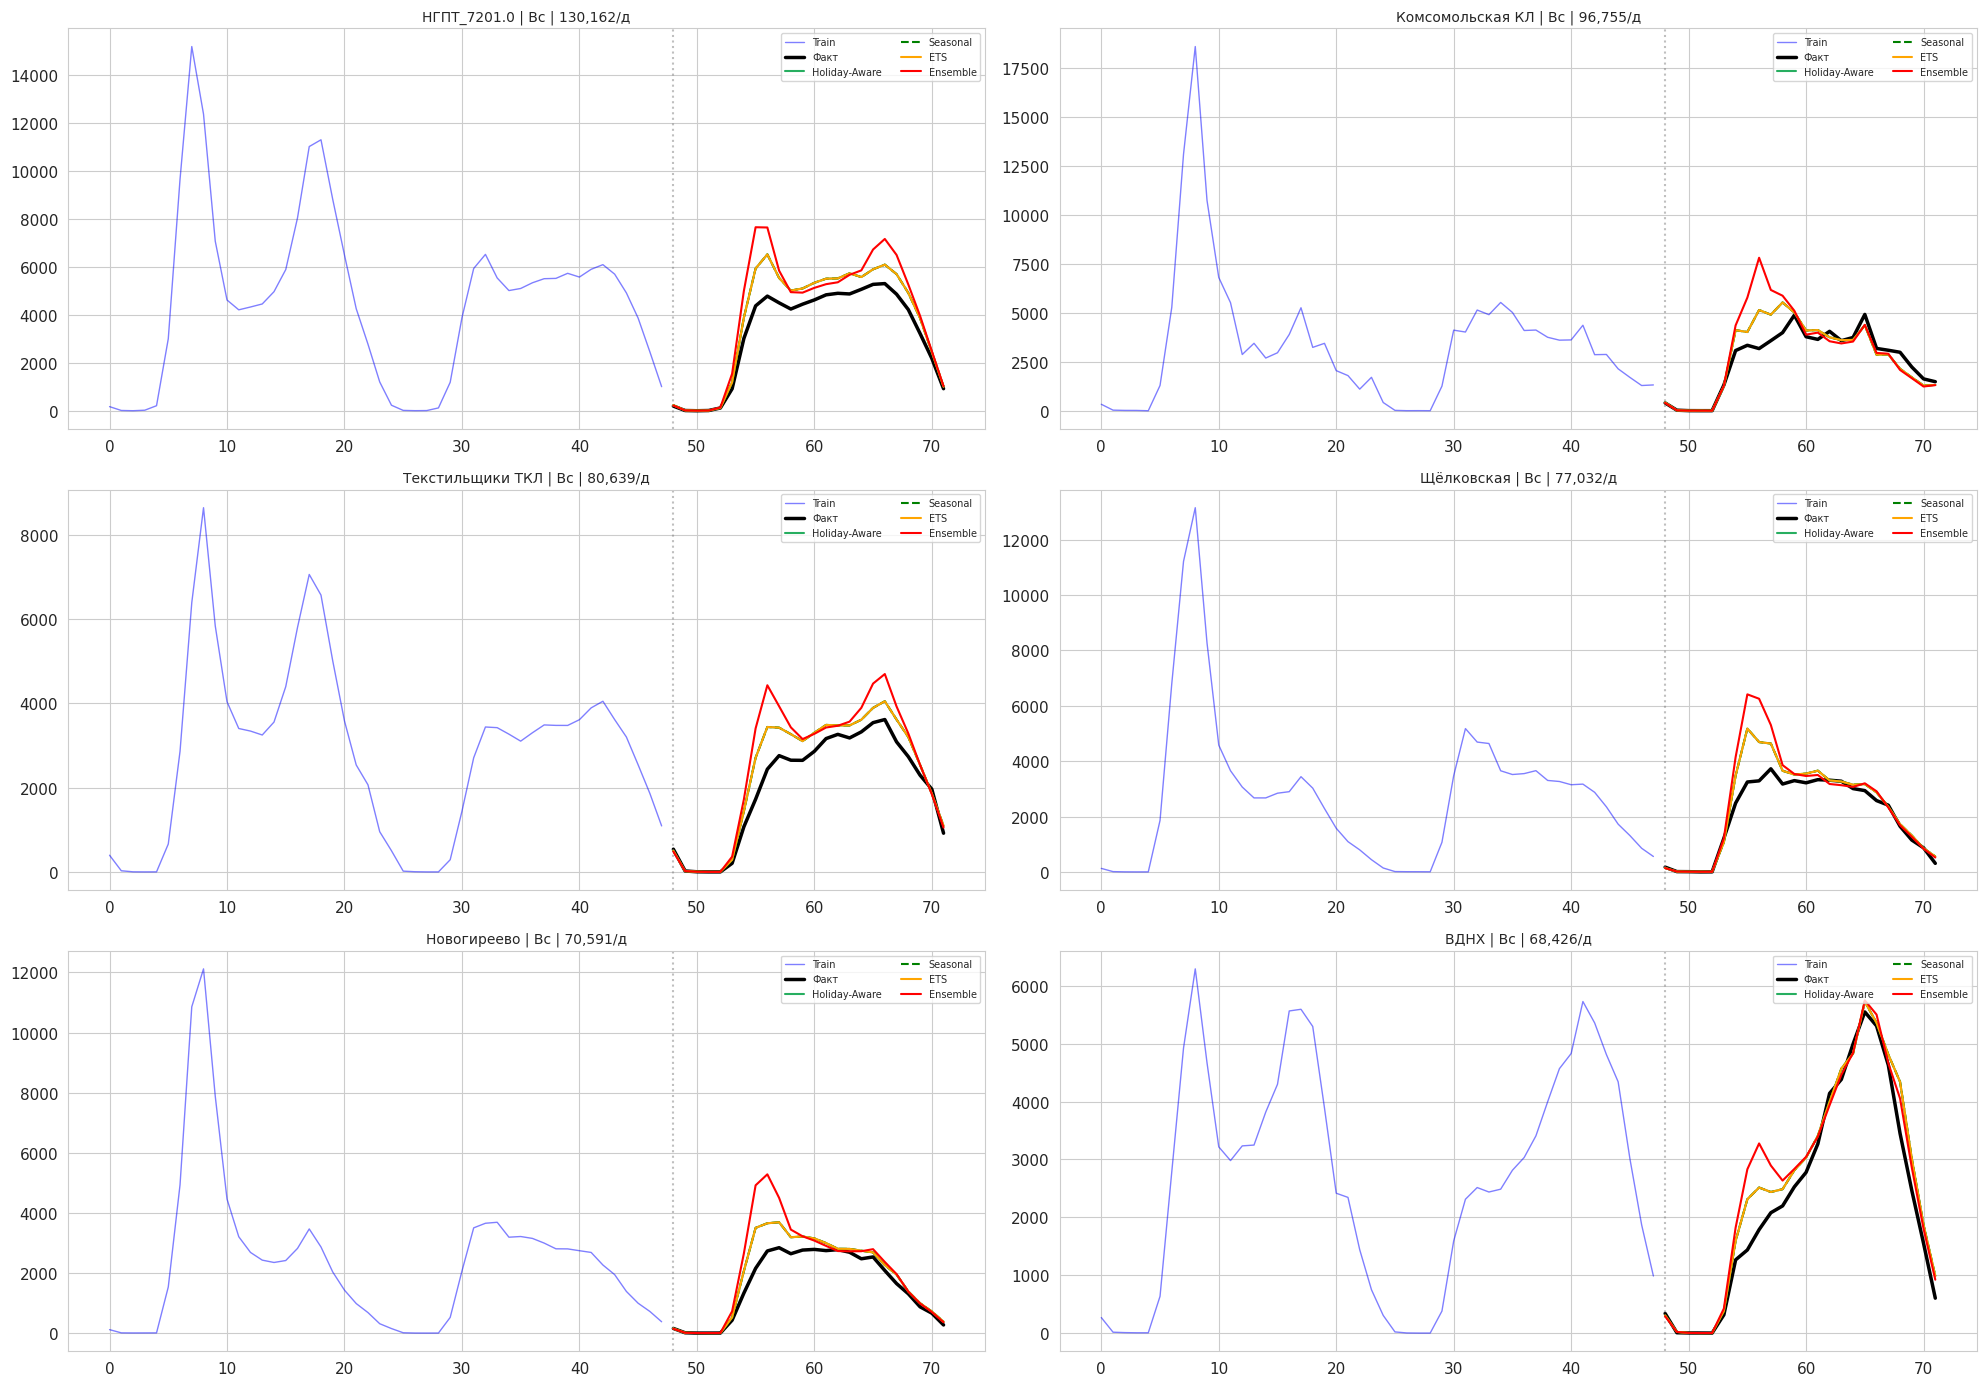

In [18]:
test_obj = all_obj.nlargest(6, 'daily_volume')
last_fold = folds_24[-1]

fig, axes = plt.subplots(3, 2, figsize=(20, 14))
axes = axes.ravel()

for idx, (_, obj) in enumerate(test_obj.iterrows()):
    ax = axes[idx]
    ts = prepare_ts(obj.object_id)
    if ts is None: continue

    y_tr = ts.iloc[:last_fold['te']]
    y_te = ts.iloc[last_fold['ts']:last_fold['tf']].values
    td = ts.index[last_fold['ts']].dayofweek
    is_hol = check_holiday(ts, last_fold['ts'])

    show = 48
    tr_show = y_tr.values[-show:]
    tr_x = range(show)
    te_x = range(show, show+len(y_te))

    ax.plot(tr_x, tr_show, 'b-', lw=1, alpha=.5, label='Train')
    ax.plot(te_x, y_te, 'k-', lw=2.5, label='Факт')
    ax.axvline(show, color='gray', ls=':', alpha=.5)

    ax.plot(te_x, holiday_aware_naive(y_tr.values, HORIZON_24, td, is_hol), color='#27ae60', ls='-', lw=1.5, label='Holiday-Aware')
    ax.plot(te_x, seasonal_naive(y_tr.values, HORIZON_24), color='green', ls='--', lw=1.5, label='Seasonal')
    ax.plot(te_x, ImprovedETS().fit_predict(y_tr.values, HORIZON_24, td, is_hol), color='orange', ls='-', lw=1.5, label='ETS')
    ax.plot(te_x, CleanEnsemble().fit_predict(y_tr.values, HORIZON_24, td, is_hol), color='red', ls='-', lw=1.5, label='Ensemble')

    hol_lbl = " [ПРАЗДНИК]" if is_hol else ""
    name_s = str(obj['name'])[:35] if pd.notna(obj['name']) else obj.object_id
    ax.set_title(f"{name_s} | {dow_names[td]}{hol_lbl} | {obj.daily_volume:,.0f}/д", fontsize=10)
    ax.legend(fontsize=7, ncol=2, loc='upper right')

plt.tight_layout(); plt.savefig('./eda_output/forecasts_24h.png', dpi=150); plt.show()

In [19]:
res_24.to_csv('./eda_output/results_24h.csv', index=False)
res_1.to_csv('./eda_output/results_1h.csv', index=False)
fin_24.to_csv('./eda_output/summary_24h.csv')
fin_1.to_csv('./eda_output/summary_1h.csv')
print(f"Сохранено: 24ч - {len(res_24):,} записей, 1ч - {len(res_1):,} записей")

Сохранено: 24ч - 61,464 записей, 1ч - 925,200 записей


## **Выводы**

**Лучшие модели** - **Same-Type Day** для 24ч (MAE 62.16) и **Seasonal-24** для 1ч (MAE 62.12). Более сложные ML-алгоритмы (k-NN, ETS, ансамбли) на 7 днях данных уступают наивным подходам из-за нехватки истории для обучения.

**Главные закономерности:**
- **Суточная ритмичность** - ключевой фактор. Прогноз "вчера в это же время" (Seasonal-24) оказался почти вдвое точнее прогноза по "прошлому часу" (Naive-1), что подтверждает жесткость графиков перемещения.
- **Разрыв по дням:** На выходных ошибка втрое выше, чем в будни (MAE ~100 vs ~34), так как поведение пассажиров становится менее детерминированным.
- **Масштабируемость:** Логика **Holiday-Aware** встроена в бейзлайн - на текущей неделе праздников не было, но модель готова к учету аномальных выходных при увеличении выборки.
- **Статистическая устойчивость:** Абсолютная ошибка растет пропорционально потоку (в Метро она выше), однако относительная точность (SMAPE) остается сопоставимой для разных видов транспорта.

Для улучшения прогноза необходимы: больше данные для обучения моделей, возможно внешние признаки (погода, городские события) и переход к глубокому обучению (LSTM/Transformer).